### **Packages install**

In [66]:
import numpy as np
import pandas as pd
import re
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

from sklearn.metrics import silhouette_score
from sklearn.cluster import AgglomerativeClustering
from collections import defaultdict
from scipy.cluster.hierarchy import dendrogram
import re
import matplotlib.pyplot as plt
?pip install sentence-transformers
?pip install tf_keras
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score
from sentence_transformers import SentenceTransformer
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
import nltk
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.corpus import words

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('words')

Object `pip install sentence-transformers` not found.
Object `pip install tf_keras` not found.


### **Data Loading**

In [88]:
#original product data with product title + breadcrumb
items_25 = pd.read_csv("/Users/cyrilestier/Desktop/data/input/items_2025.csv") 
#original price data with unit_price x loyalty price x orignal_price
prices_df = pd.read_csv("/Users/cyrilestier/Desktop/data/input/prices_2025_cross_section.csv")
#sam's categorized data with summary, description, TSD = title + summary + description, processed, breadcrumb_clean, Category, title summary 
categorized = pd.read_csv("/Users/cyrilestier/Desktop/data/input/categorized_items5.csv")
#hand labelled data with our own product gender labels 
hand_label = pd.read_csv("/Users/cyrilestier/Desktop/data/input/combined.csv")
#second batch of hand labelled data 
hand_label_sam = pd.read_csv("/Users/cyrilestier/Desktop/data/input/hand_labeling2_sb.csv")
hand_label_cyril = pd.read_csv("/Users/cyrilestier/Desktop/data/input/hand_labeling2.csv")

---

# <span style="background-color: yellow">**Pre-processing Pipeline**</span> 
Sam's preprocessing pipeline: 1) Merging and processing descriptions  2) Categorization

### Merging and processing

In [ ]:
tesco_desc = pd.read_csv("../Final Project/tesco_parsed.csv")
asda_desc = pd.read_csv("../Final Project/asda_parsed_item_info.csv")
morrisons_desc = pd.read_csv("../Final Project/detailed_item_info_morrisons_2025-03-18_10-46-10.csv")
waitrose_desc = pd.read_csv("../Final Project/all_waitrose_item_info.csv")
sainsburys_desc = pd.read_csv("../Final Project/sainsburys_product_details.csv")

cols = ['store_id','product_id','product_title','summary','description', 'category']
item_desc = pd.concat([tesco_desc[cols],sainsburys_desc[cols],asda_desc[cols],morrisons_desc[cols],waitrose_desc[cols]])
item_desc_merge = item_desc.merge(items_25[['store_id','product_id','product_breadcrumb','product_url']], how='left', on=['store_id', 'product_id'])
item_desc_merge['product_title'] = item_desc_merge['product_title'].fillna('')
item_desc_merge['summary'] = item_desc_merge['summary'].fillna('')
item_desc_merge['description'] = item_desc_merge['description'].fillna('')
item_desc_merge['product_breadcrumb'] = item_desc_merge['product_breadcrumb'].fillna('')

stop_words = stopwords.words('english')
english_words = set(words.words())

# Preprocessing function
def preprocess_text(text):
    text = text.lower()  # Lowercase
    text = re.sub(r'[^a-z\s]', '', text)  # Remove punctuation
    tokens = word_tokenize(text)  # Tokenize
    lemmatizer = WordNetLemmatizer()
    tokens = [lemmatizer.lemmatize(word) for word in tokens]  # Lemmatize
    tokens = [word for word in tokens if word not in stopwords.words('english')]  # Remove stopwords
    tokens = [word for word in tokens if word in english_words]  # Remove non-english words
    return " ".join(tokens)

# Apply preprocessing
item_desc_merge['TSDB'] = item_desc_merge['TSDB'].astype(str)
item_desc_merge['processed'] = item_desc_merge['TSDB'].apply(preprocess_text)


all_data_processed = item_desc_merge

### Categorizing by products 
 We selected categories at our own discretion based on whether they were more likely to be gendered products. This gave us the possibility of narrowing down and have a more balanced data set.

In [ ]:
# Append product title to the end of breadcrumb as final breadcrumb
items_25['breadcrumb_title'] = items_25['product_breadcrumb'] + ',' + items_25['product_title']

In [ ]:
# Define keyword categories
keyword_sets = {
    "Other": {"fabric", "cigarette", "cigar", "meal", "frozen", "shaver adapter", "beard oil", "food", "candle", "candles", "birthday card", "unperfumed", "pet", "hand sanitiser"},
    "Body Wash": {"body wash", "shower gel", "body soap"},
    "Shampoo/Conditioner": {"shampoo", "hair wash", "hair cleanser", "conditioner", "hair softener", "hair mask", "hydrating mask", "hair moisturizer", "hair moisturiser"},
    "Razors": {"razor", "shaver", "trimmer", "epilator"},
    "Shaving Cream": {"shaving cream", "shaving foam", "shaving gel", "shaving lotion", "shave cream", "razor cream", "shaving butter", "pre-shave cream", "lathering cream", "shaving soap"},
    "Perfume/Cologne": {"perfume", "cologne", "eau de toilette", "eau de parfum", "parfum", "aftershave", "body mist"}, 
    "Deodorant": {"deodorant", "antiperspirant", "deodorizing spray", "body spray"},
    "Supplements": {"Vitamin", "Omega-3", "supplement", "enzyme", "energy tablet"},
    "Oral Care": {"toothpaste", "toothbrush", "mouthwash", "dental floss", "water pick", "whitening strips", "interspace brush", "interdental brush", "toothpowder", "flosser"},
    "Skincare": {"SPF","sunscreen","lotion", "moisturiser", "moisturizer", "ointment", "balm", "body butter", "face cleanser", "facial cleanser", "face cleansing", "facial cleansing", "lip balm", "face cream", "facial cream"},
    "Vape": {"vape","vaporisor","vaporizer", "vape pod", "vape liquid", "vaping pod", "vaping liquid", "e-cig"},
    "Hair Dye": {"hair dye", "hair color", "hair colour", "hair bleach"},
    "Adult Intimacy": {"condom", "lubricant", "adult toy", "vibrator", "adult toy", "adult device", "intimate gel"},
    #"Kids Toys": {"toy", "game", "play"},
    "Cleaning Liquid": {"disinfectant", "bleach", "degreaser", "sanitizer", "sanitiser", "surface spray", "floor cleaner", "floor spray", "counter cleaner", "counter spray", "carpet cleaner", "carpet spray", "glass spray", "glass cleaner", "mirror cleaner", "mirror spray", "steel cleaner", "steel spray"}
}

# Dictionary to store classification results: {store_id: {product_id: "Category"}}
categorized_products = defaultdict(dict)

for store_id, products in breadcrumbs_dict.items():
    for product_id, breadcrumb_list in products.items():
        if not breadcrumb_list:  # Skip empty breadcrumbs
            continue
        
        # If the second breadcrumb is "Perfumes" in Store 1, replace it with an empty string
        # There is an issue with TESCO where they put some non-perfume items under the perfume category. This removes those categories, so we don't pick up non-Perfumes
        if store_id == 1 and len(breadcrumb_list) > 2 and breadcrumb_list[1].lower() == "perfumes" and breadcrumb_list[2].lower() == "aftershaves & gift sets":
            breadcrumb_list[1] = ""  # Replace the second-to-last breadcrumb with an empty string
            breadcrumb_list[2] = ""  # Replace the third-to-last breadcrumb with an empty string
        
        # Iterate from last breadcrumb backwards
        classified = False
        for breadcrumb in reversed(breadcrumb_list):
            breadcrumb_lower = breadcrumb.lower()
            
            # Check each keyword category
            for category, keywords in keyword_sets.items():
                if any(keyword in breadcrumb_lower for keyword in keywords):
                    categorized_products[store_id][product_id] = category
                    classified = True
                    break  # Stop searching once classified
            
            if classified:
                break  # Stop searching once classified
        
        # If no match was found, classify as "Other"
        if not classified:
            categorized_products[store_id][product_id] = "Other"

# Convert the categorized dictionary to a DataFrame
items = []

for store_id, products in categorized_products.items():
    for product_id, category in products.items():
        breadcrumb_list = breadcrumbs_dict.get(store_id, {}).get(product_id, [])
        breadcrumb_clean = " | ".join(breadcrumb_list)  # Combine the breadcrumb list into a single string
        items.append({
            "store_id": store_id,
            "product_id": product_id,
            "breadcrumb_clean": breadcrumb_clean,
            "category": category
        })

# Create the pandas DataFrame
items_bc = pd.DataFrame(items)


items_desc = all_data_processed

# Merge item descriptions with product categories based on breadcrerumbs
items_desc_sub = items_desc[['store_id','product_id','product_title','summary','description','product_breadcrumb','TSDB','processed','product_url']]
items_merge = items_desc_sub.merge(items_bc, how='left', on=['store_id','product_id'])
# limit items to those that are categorized
items_limit = items_merge[(~items_merge['category'].isna()) & (items_merge['category'] != 'Other')]

categorized_items5 = items_limit


In [ ]:
# Create a function to split breadcrumbs into list
def breadcrumbs(product_breadcrumb, store_id, product_id):
    # Remove unwanted characters (e.g., [ ] " ')
    clean_breadcrumb = re.sub(r'[\]\[\"\']', '', product_breadcrumb)
    
    # Define possible splitters
    possible_splitters = [',', '/', '>']

    # Replace all splitters with a common delimiter (e.g., space) for uniform splitting
    for splitter in possible_splitters:
        clean_breadcrumb = clean_breadcrumb.replace(splitter, '|')

    # Split the breadcrumb into parts based on spaces
    split_breadcrumb = [i.strip() for i in clean_breadcrumb.split('|') if i.strip()]  # Strip spaces and remove empty parts

    return {product_id: split_breadcrumb}


# Dictionary to store breadcrumbs structured by store_id
breadcrumbs_dict = {}

def breadcrumb_run(df):
    for i in range(len(df)):
        store_id = df.loc[i, 'store_id']
        product_id = df.loc[i, 'product_id']
        product_breadcrumb = df.loc[i, 'breadcrumb_title']
        
        # Ensure store_id exists in dictionary
        if store_id not in breadcrumbs_dict:
            breadcrumbs_dict[store_id] = {}

        # Process and store breadcrumbs using the breadcrumbs function
        breadcrumbs_dict[store_id].update(breadcrumbs(product_breadcrumb, store_id, product_id))

# Apply breadcrumb run to items
breadcrumb_run(items_25)

# <span style="background-color: yellow">**Making our training data set**</span>  
We need a training data set for our model, our first set will be using explicit labels.
If products have keywords associated with male or female with rather high confidence, they are explicitly labelled as such. If neither male or female, it is given the neutral label. Important to note that the neutral label here is not definitive yet since they are simply non-explictly male or female. 
If products have the female keywords it is assigned 0
If products have the male keywords it is assigned 1 
If products have the neither keywords it is assigned 2 

### Creating an explicit gender labelling 

In [68]:
#STEP 1 -> Find explicit labels
#Subjective words -> we could add more here. 
#New column called "product_gender" with 0,1,2.
#Note: Whether its upper case or not, is not taken into account.
male_keywords = {"men", "male", "boy", "gentlemen", "gents", "his", "masculine", "boys", "man"}
female_keywords = {"women", "female", "girl", "ladies", "her", "feminine", "lady","woman","girls"}

male_pattern = re.compile(r'\b(?:' + '|'.join(re.escape(word) for word in male_keywords) + r')\b', flags=re.IGNORECASE)
female_pattern = re.compile(r'\b(?:' + '|'.join(re.escape(word) for word in female_keywords) + r')\b', flags=re.IGNORECASE)

def classify_product_gender(title: str) -> int:
    title = title.lower() if isinstance(title, str) else ""
    
    male_match = bool(male_pattern.search(title))
    female_match = bool(female_pattern.search(title))
    
    if male_match and female_match:
        return 2  # Neutral
    if male_match:
        return 1  # Male
    if female_match:
        return 0  # Female
    return 2

categorized["product_gender"] = categorized["processed"].apply(classify_product_gender)
explicit_label = categorized[categorized["product_gender"].isin([0, 1])]
explicit_label = explicit_label.rename(columns={'TSD_x': 'TSD'})
explicit_label.shape

(1904, 13)

In [69]:
#STEP 2 -> Remove keywords from the description
#All similar keywords for male and women are taken out. 
gender_terms = ["men", "male", "boy", "gentlemen", "gents", "his", "masculine", "boys", "man","women", "female", "girl", "ladies", "her", "feminine", "lady","woman","girls"]
gender_pattern = re.compile(r'\b(?:' + '|'.join(re.escape(term) for term in gender_terms) + r')\b', flags=re.IGNORECASE)

# Define the function to clean a single string
def strip_gender_terms(text):
    if not isinstance(text, str):
        return ""
    return gender_pattern.sub('', text).strip()

# Apply it to the 'full_descr' column
explicit_label['processed'] = explicit_label['processed'].apply(strip_gender_terms)


### Creating a gender hand labelling
Since we didn't have any confirmed neutral labels, we hand labelled some data. We each assigned in slightly different gender labels format so we first clean it. 

In [70]:
#Processing just to make sure the labelling is in numerical format
hand_label['label'] = hand_label['label'].replace('neutral', 2)
hand_label['label'] = hand_label['label'].replace('Neutral', 2)
hand_label['label'] = hand_label['label'].replace('female', 0)
hand_label['label'] = hand_label['label'].replace('Female', 0)
hand_label['label'] = hand_label['label'].replace('Male', 1)
hand_label['label'] = hand_label['label'].replace('male', 1)
hand_label = hand_label.rename(columns={'label': 'product_gender'})

/var/folders/dx/505c01650qnflnz6sd29qqsh0000gn/T/ipykernel_30144/746683233.py:7: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  hand_label['label'] = hand_label['label'].replace('male', 1)


### Combining Hand labels with explicit labels

In [71]:
#STEP 1 -> Merging hand_labelled data with categorized data to get the processed descriptions
#Did it  based on product_url to make sure it worked, all observations were kept. Lets go
#Once this data is merged it means we have a fully hand_labelled data with Sam's processed descriptions & categorizations
hand_data = pd.merge(hand_label, categorized, on=['product_url'],how='inner')
hand_data = hand_data[['product_id_x','TSDB','store_id_x','product_gender_x','product_url','processed_y']]
hand_data = hand_data.rename(columns={'product_id_x': 'product_id'})
hand_data = hand_data.rename(columns={'store_id_x': 'store_id'})
hand_data = hand_data.rename(columns={'product_gender_x': 'product_gender'})
hand_data = hand_data.rename(columns={'processed_y': 'processed'})

In [72]:
#Step 2 -> Merging 
training_data = pd.merge(hand_data, explicit_label, on=['product_url'],how='outer', suffixes=('_explicit', '_hand'))
training_data['gender_label'] = training_data['product_gender_hand'].combine_first(training_data['product_gender_explicit'])
training_data['TSDB'] = training_data['TSDB_hand'].combine_first(training_data['TSDB_explicit'])
training_data['product_id'] = training_data['product_id_explicit'].combine_first(training_data['product_id_hand'])
training_data['store_id'] = training_data['store_id_hand'].combine_first(training_data['store_id_explicit'])
training_data['processed'] = training_data['processed_explicit'].combine_first(training_data['processed_hand'])
training_data = training_data[['product_id','TSDB','store_id','processed','gender_label','product_url']]
training_data.columns, training_data.shape

(Index(['product_id', 'TSDB', 'store_id', 'processed', 'gender_label',
        'product_url'],
       dtype='object'),
 (2034, 6))

# <span style="background-color: yellow">**Model 1 - Logistic Regression using text embedding**</span>  
We need to encode our text into vector representations to use as training-test data.

### Data Embedding 

In [73]:
#X is the processed text, Y is the outcome which is the gender label (0,1,2)
X = training_data['processed']
y = training_data['gender_label']

#We use a pre-trained text embedder to convert the text into vectors, we should try how different models work
text_embed = SentenceTransformer("all-MiniLM-L6-v2")
X_embed = text_embed.encode(X.tolist(), convert_to_tensor=False)




### Splitting data
Now after embedding we split the data. 

In [74]:
#Split data into training and testing 
X_train, X_test, y_train, y_test = train_test_split(X_embed, y, test_size=0.3, random_state=42)
y_train.value_counts(), y_test.value_counts()
#While there's a good balance of male and female, there's little neutral data. Only 48 neutral in the training, and 18 in the test set. This means our accuracy rate might be biased. 

(gender_label
 1.0    739
 0.0    636
 2.0     48
 Name: count, dtype: int64,
 gender_label
 1.0    335
 0.0    258
 2.0     18
 Name: count, dtype: int64)

### Running a Multinomial LogisticRegression
Using a three variable logistic regression. We could test others? 

In [75]:
text_embedding_model = LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=200)
text_embedding_model.fit(X_train, y_train)
y_pred = text_embedding_model.predict(X_test)

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


### Evaluation

In [76]:
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.8314238952536824


In [77]:
print("Classification Report:\n", classification_report(y_test, y_pred))

#Reminder of precision and recall
#Precision = true positive / (true positive + false positive) = 
#Recall = true positive / (true positive + false negative)

Classification Report:
               precision    recall  f1-score   support

         0.0       0.79      0.85      0.82       258
         1.0       0.87      0.84      0.85       335
         2.0       1.00      0.39      0.56        18

    accuracy                           0.83       611
   macro avg       0.88      0.69      0.74       611
weighted avg       0.84      0.83      0.83       611



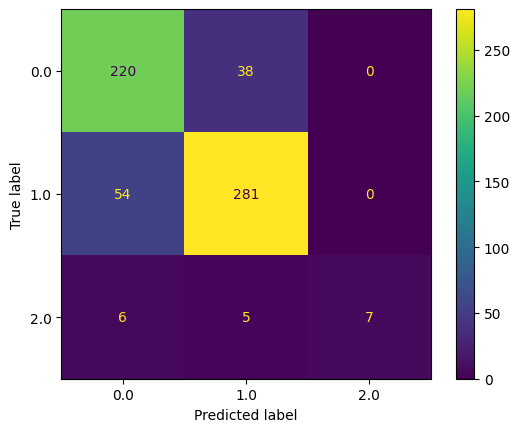

In [78]:
cm = confusion_matrix(y_test, y_pred, labels=text_embedding_model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=text_embedding_model.classes_)
disp.plot()

### Out of Sample Test 
Curious to test out on rest of the data set to see whether we have gender. 

In [79]:
categorized.columns

Index(['Unnamed: 0', 'store_id', 'product_id', 'product_title', 'summary',
       'description', 'product_breadcrumb', 'TSDB', 'processed', 'product_url',
       'breadcrumb_clean', 'category', 'product_gender'],
      dtype='object')

In [80]:
oos_test = categorized.sample(n=800, random_state=42)
X_oos_test = oos_test['processed']
X_oos_embed = text_embed.encode(X_oos_test.tolist(), convert_to_tensor=False)
oos_preds = text_embedding_model.predict(X_oos_embed)

oos_test['oos_gender'] = oos_preds


#oos_test[['processed', 'product_gender', 'oos_gender']].head(10)
# Check the value at index 1 in the 'processed' column

#with pd.option_context('display.max_colwidth', None, 'display.max_columns', None, 'display.width', None):
#    print(oos_test[['product_url','product_gender', 'oos_gender']].head(10))

oos_test['oos_gender'].unique()


array([0., 2., 1.])

In [87]:
oos_test['oos_gender'].value_counts()

grouped_test = oos_test.groupby('category')['oos_gender'].value_counts().unstack(fill_value=0)
print(grouped_test)

oos_gender           0.0  1.0  2.0
category                          
Adult Intimacy         2    7    0
Body Wash             34   57    0
Cleaning Liquid        3    8    5
Deodorant             31   43    0
Hair Dye              42    4    0
Oral Care             10   57   25
Perfume/Cologne       11    5    0
Razors                21   36    0
Shampoo/Conditioner  118   13    0
Shaving Cream          2    4    0
Skincare              87   29    2
Supplements           72   28    0
Vape                  10    6   28


# <span style="background-color: yellow">**Model 2 - Logistic regression using image**</span>   
